In [ ]:
import numpy as np

from qiskit import QuantumCircuit
from qiskit.transpiler import PassManager
from qiskit.transpiler.passes import (
    UnitarySynthesis,
    Optimize1qGatesDecomposition,
    CommutativeCancellation,
)
from qiskit.circuit.library import UnitaryGate, CCZGate, CSwapGate, XXPlusYYGate, SGate, SdgGate


from qiskit.quantum_info import Statevector, state_fidelity

from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error, thermal_relaxation_error

from implementation import EnergyConservingDecompositionPass

def get_standrad_vs_ec_decompositions(qc: QuantumCircuit):
    pm = PassManager([
        UnitarySynthesis(basis_gates=["rz", "cx"]),
        Optimize1qGatesDecomposition(),
        CommutativeCancellation(),
    ])

    ec_pm = PassManager([
        EnergyConservingDecompositionPass(),
        Optimize1qGatesDecomposition(),
        CommutativeCancellation(),
    ])

    qc_decomposed = pm.run(qc)
    qc_ec_decomposed = ec_pm.run(qc)
    return qc_decomposed, qc_ec_decomposed


def add_controlled_exp_i_theta_swap(qc: QuantumCircuit, theta: float, control: int, q0: int, q1: int):
    """Append controlled e^{i θ SWAP} acting on qubits (q0, q1) with control qubit."""
    swap = np.array(
        [
            [1, 0, 0, 0],
            [0, 0, 1, 0],
            [0, 1, 0, 0],
            [0, 0, 0, 1],
        ],
        dtype=complex,
    )
    U = exp_i_theta_involution(swap, theta)
    
    # Create controlled unitary gate
    controlled_U = UnitaryGate(U, label="$exp^{i\\theta \\; SWAP}$").control()
    qc.append(controlled_U, [control, q0, q1])
    return qc

def add_exp_i_theta_swap_kron_swap(qc: QuantumCircuit, theta: float, q0: int, q1: int, q2: int, q3: int):
    """Append e^{i θ (SWAP ⊗ SWAP)} on qubits (q0,q1,q2,q3)."""
    swap = np.array(
        [
            [1, 0, 0, 0],
            [0, 0, 1, 0],
            [0, 1, 0, 0],
            [0, 0, 0, 1],
        ],
        dtype=complex,
    )
    swap_kron = np.kron(swap, swap)  # SWAP ⊗ SWAP
    U = exp_i_theta_involution(swap_kron, theta)
    gate = UnitaryGate(U, label="$exp^{i\\theta \\; SWAP\\otimes SWAP}$")
    qc.append(gate, [q0, q1, q2, q3])
    return qc


def add_CCZ(qc: QuantumCircuit, q0: int, q1: int, q2: int):
    """Append a CCZ gate on (q0, q1, q2)."""
    qc.append(CCZGate(), [q0, q1, q2])
    return qc


def add_CSWAP(qc: QuantumCircuit, qc0: int, q1: int, q2: int):
    """Append a CSWAP (Fredkin) gate on (control, target1, target2)."""
    qc.append(CSwapGate(), [qc0, q1, q2])
    return qc


def add_exp_i_theta_CSWAP(qc: QuantumCircuit, theta: float, qc0: int, q1: int, q2: int):
    """Append e^{i θ CSWAP} on (control, target1, target2)."""
    # Build the CSWAP matrix once using a small auxiliary circuit
    aux = QuantumCircuit(3)
    aux.cswap(0, 1, 2)
    cswap_matrix = Operator(aux).data  # 8x8

    U = exp_i_theta_involution(cswap_matrix, theta)
    gate = UnitaryGate(U, label="$exp^{i\\theta \\;CSWAP}$")
    qc.append(gate, [qc0, q1, q2])
    return qc



def make_noise_model_for_circuit(
    qc: QuantumCircuit,
    p1: float = 0.001,   # 1q depolarizing
    p2: float = 0.01,    # 2q depolarizing
    use_t1t2: bool = False,
    t1: float = 50e3,    # ns
    t2: float = 70e3,    # ns
    gate_1q_time: float = 50.0,   # ns
    gate_2q_time: float = 300.0,  # ns
) -> NoiseModel:
    """
    Builds a noise model that:
    - Applies depolarizing to all 1q/2q gates that appear in qc
    - Optionally composes thermal relaxation (T1/T2) on top
    """
    nm = NoiseModel()

    # Identify which gate names appear
    gate_names = [inst.operation.name for inst in qc.data]

    one_q = sorted({g for g in gate_names if g not in ("barrier",) and len(_qargs(inst=None, name=g)) == 1})
    two_q = sorted({g for g in gate_names if g not in ("barrier",) and len(_qargs(inst=None, name=g)) == 2})

    # Fallback: if above inference fails, use a safer method (count qubits per instruction)
    one_q, two_q = set(), set()
    for inst in qc.data:
        if inst.operation.name == "barrier":
            continue
        nq = len(inst.qubits)
        if nq == 1:
            one_q.add(inst.operation.name)
        elif nq == 2:
            two_q.add(inst.operation.name)

    one_q = sorted(one_q)
    two_q = sorted(two_q)

    # Depolarizing errors
    if one_q:
        err1 = depolarizing_error(p1, 1)
        if use_t1t2:
            therm1 = thermal_relaxation_error(t1, t2, gate_1q_time)
            err1 = err1.compose(therm1)
        for g in one_q:
            nm.add_all_qubit_quantum_error(err1, g)

    if two_q:
        err2 = depolarizing_error(p2, 2)
        if use_t1t2:
            therm2 = thermal_relaxation_error(t1, t2, gate_2q_time).tensor(
                thermal_relaxation_error(t1, t2, gate_2q_time)
            )
            err2 = err2.compose(therm2)
        for g in two_q:
            nm.add_all_qubit_quantum_error(err2, g)

    return nm


def _qargs(inst=None, name=None):
    """
    Dummy helper kept only so earlier set-comprehension doesn't crash if you remove it.
    We do the safe inference later from qc.data anyway.
    """
    return []





# if __name__ == "__main__":
#     # 1) Build an energy-conserving circuit

#     # 2) Decompose two ways
#     qc_std, qc_ec = get_standrad_vs_ec_decompositions(qc)

#     # 3) Simulate under noise and compare
#     simulate_fidelity_vs_noise(
#         qc_ideal=qc,
#         qc_std=qc_std,
#         qc_ec=qc_ec,
#         p2_list=(0.0, 0.002, 0.005, 0.01, 0.02),
#         p1_ratio=0.1,
#         use_t1t2=False,  # flip True to include a simple T1/T2 component
#     )


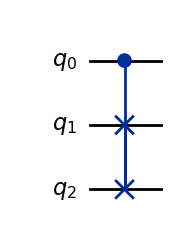

In [11]:
qc = QuantumCircuit(3)
qc = add_CSWAP(qc, qc0=0, q1=1, q2=2)
qc.draw("mpl")

In [15]:
qc_std, qc_ec = get_standrad_vs_ec_decompositions(qc)

In [5]:
simulate_fidelity_vs_noise(
    qc_ideal=qc,
    qc_std=qc_std,
    qc_ec=qc_ec,
    p2_list=(0.0, 0.002, 0.005, 0.01, 0.02),
    p1_ratio=0.1,
    use_t1t2=False,  # flip True to include a simple T1/T2 component
)

Gate counts:
  ideal: depth=13, size=21
  std : depth=12, size=20
  ec  : depth=33, size=51



AerError: 'unknown instruction: xx_plus_yy'

In [19]:
# Normalize to SU(block_size)
import numpy as np

block = np.array([
    [1, 1],
    [1, np.exp(1j * np.pi/4)]
])
det_block = np.linalg.det(block)
print("Determinant of block:", det_block)

D = np.eye(2, dtype=complex)
D[0, 0] = np.exp(-1j * np.angle(det_block))
print("Normalization matrix D:", D)

su_block = D @ block
# hw_phases[hw] np.angle(det_block)
print("SU-normalized block:", su_block)
print("Determinant of SU-normalized block:", np.linalg.det(su_block))


Determinant of block: (-0.2928932188134524+0.7071067811865475j)
Normalization matrix D: [[-0.38268343-0.92387953j  0.        +0.j        ]
 [ 0.        +0.j          1.        +0.j        ]]
SU-normalized block: [[-0.38268343-0.92387953j -0.38268343-0.92387953j]
 [ 1.        +0.j          0.70710678+0.70710678j]]
Determinant of SU-normalized block: (0.7653668647301793+1.6558710041174912e-17j)
